In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.chdir("/content/drive/My Drive/Colab Notebooks")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
dataset = pd.read_excel("polynomial_dataset_mixed.xlsx")

In [ ]:
X = dataset[['Advertising_Budget']].values
y = dataset['Monthly_Sales'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test_poly)


In [ ]:
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.9787389471406466


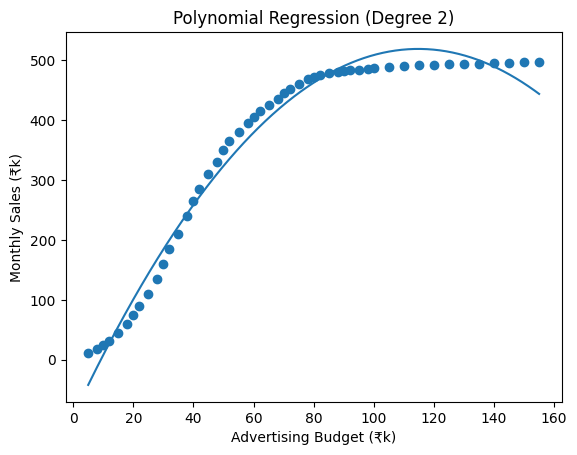

In [ ]:
plt.scatter(X, y)
X_grid = np.linspace(min(X), max(X), 500).reshape(-1,1)
plt.plot(X_grid, model.predict(poly.transform(X_grid)))
plt.xlabel("Advertising Budget (₹k)")
plt.ylabel("Monthly Sales (₹k)")
plt.title("Polynomial Regression (Degree 2)")
plt.show()